Part 1
Slope (m): 0.9500000000000001, Intercept (c): 0.5900000000000001


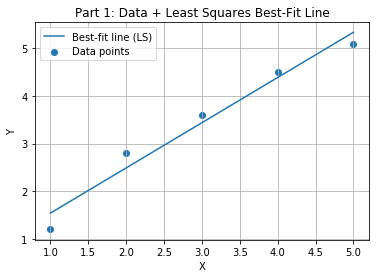


Part 2
Randomized Y: [4.5 3.6 5.1 2.8 1.2]
Slope (m): -0.7399999999999998, Intercept (c): 5.659999999999999


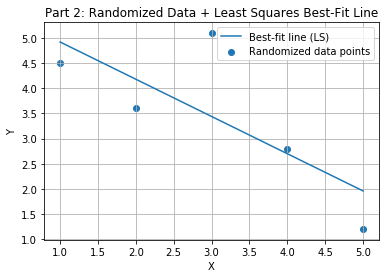


Part 3
True line:      y = 2.3x + -0.4
Recovered line: y = 2.287398241685492x + -0.40829604510422907


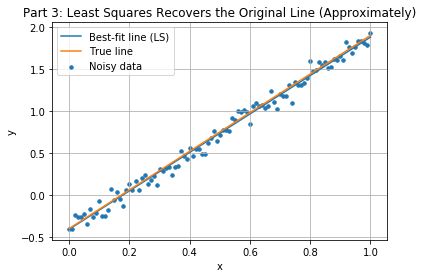

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Part 1:
X = np.array([1, 2, 3, 4, 5], dtype=float)
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1], dtype=float)

A = np.vstack([X, np.ones(len(X))]).T

m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print("Part 1")
print(f"Slope (m): {m}, Intercept (c): {c}")

Y_fit = m * X + c
plt.figure()
plt.scatter(X, Y, label="Data points")
plt.plot(X, Y_fit, label="Best-fit line (LS)")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Part 1: Data + Least Squares Best-Fit Line")
plt.grid(True)
plt.legend()
plt.show()

# Part 2: 
rng = np.random.default_rng(67)
Y_rand = Y.copy()
rng.shuffle(Y_rand)

A2 = np.vstack([X, np.ones(len(X))]).T
m2, c2 = np.linalg.lstsq(A2, Y_rand, rcond=None)[0]
print("\nPart 2")
print("Randomized Y:", Y_rand)
print(f"Slope (m): {m2}, Intercept (c): {c2}")

Y_fit2 = m2 * X + c2
plt.figure()
plt.scatter(X, Y_rand, label="Randomized data points")
plt.plot(X, Y_fit2, label="Best-fit line (LS)")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Part 2: Randomized Data + Least Squares Best-Fit Line")
plt.grid(True)
plt.legend()
plt.show()

# Part 3: 
m_true = 2.3
c_true = -0.4

x3 = np.arange(0, 1.01, 0.01) 
noise = rng.normal(loc=0.0, scale=0.08, size=len(x3))  
y3 = m_true * x3 + c_true + noise

A3 = np.vstack([x3, np.ones(len(x3))]).T
m3, c3 = np.linalg.lstsq(A3, y3, rcond=None)[0]
print("\nPart 3")
print(f"True line:      y = {m_true}x + {c_true}")
print(f"Recovered line: y = {m3}x + {c3}")

y3_fit = m3 * x3 + c3
y3_true = m_true * x3 + c_true

plt.figure()
plt.scatter(x3, y3, s=12, label="Noisy data")
plt.plot(x3, y3_fit, label="Best-fit line (LS)")
plt.plot(x3, y3_true, label="True line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Part 3: Least Squares Recovers the Original Line (Approximately)")
plt.grid(True)
plt.legend()
plt.show()